In [95]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split


In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [ ]:
class EyeTrackingDataset(Dataset):
    def __init__(self, csv_file, img_dir, img_size=(224,224), transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.img_size = img_size
        self.transform = transform

        valid_rows = []
        img_paths = []


        for i, row in self.df.iterrows():
            fid = int(row['frame_id'])
            path = os.path.join(img_dir, f"frame_{fid:04d}.png")
            if os.path.exists(path):
                valid_rows.append(row)
                img_paths.append(path)

        # on garde uniquement les lignes valides
        self.df = pd.DataFrame(valid_rows).reset_index(drop=True)
        self.img_paths = img_paths

        self.coords = self.df[['x','y']].values.astype(np.float32)

        print(f"Dataset loaded with {len(self.df)} valid frames")

        print(f"Dataset loaded with {len(self.df)} valid frames")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]

        img = cv2.imread(img_path)
        if img is None:
            raise RuntimeError(f"Failed to load image: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # normalisation 
        h0, w0, _ = img.shape
        x, y = self.coords[idx]
        label = torch.tensor([x / w0, y / h0], dtype=torch.float32)
        label = torch.clamp(label, 0.0, 1.0)

        img = cv2.resize(img, self.img_size)

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
            img = transforms.Normalize([0.5,0.5,0.5],
                                       [0.5,0.5,0.5])(img)

        return img, label


In [78]:
csv_file = "data/coords.csv"
img_dir  = "data/frames"

dataset = EyeTrackingDataset(csv_file, img_dir)

indices = np.arange(len(dataset))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
dev_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_ds = Subset(dataset, train_idx)
dev_ds   = Subset(dataset, dev_idx)
test_ds  = Subset(dataset, test_idx)

print("Train size:", len(train_ds))
print("Dev size:", len(dev_ds))
print("Test size:", len(test_ds))


Dataset loaded with 1785 valid frames
Dataset loaded with 1785 valid frames
Train size: 1249
Dev size: 268
Test size: 268


In [98]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
dev_loader   = DataLoader(dev_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)


In [99]:
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)


torch.Size([32, 3, 224, 224]) torch.Size([32, 2])


In [100]:
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)
print(labels.min(), labels.max())


torch.Size([32, 3, 224, 224]) torch.Size([32, 2])
tensor(0.1333) tensor(1.)


In [101]:
class EyeTrackingCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.regressor = nn.Linear(64, 2)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.regressor(x)
        return torch.sigmoid(x)  # force [0,1]


In [102]:
model = EyeTrackingCNN()


In [103]:
model = EyeTrackingCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 5
train_losses = []
dev_losses = []

for epoch in range(epochs):
    # ---------- TRAIN ----------
    model.train()
    running_train_loss = 0.0

    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_mse = running_train_loss / len(train_loader)
    train_losses.append(train_mse)

    # ---------- DEV ----------
    model.eval()
    running_dev_loss = 0.0

    with torch.no_grad():
        for imgs, targets in dev_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            preds = model(imgs)
            loss = criterion(preds, targets)
            running_dev_loss += loss.item()

    dev_mse = running_dev_loss / len(dev_loader)
    dev_losses.append(dev_mse)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train MSE: {train_mse:.4f} | "
        f"Dev MSE: {dev_mse:.4f}"
    )


Epoch 1/5 | Train MSE: 0.0887 | Dev MSE: 0.0502
Epoch 2/5 | Train MSE: 0.0525 | Dev MSE: 0.0528
Epoch 3/5 | Train MSE: 0.0471 | Dev MSE: 0.0504
Epoch 4/5 | Train MSE: 0.0455 | Dev MSE: 0.0501
Epoch 5/5 | Train MSE: 0.0451 | Dev MSE: 0.0500


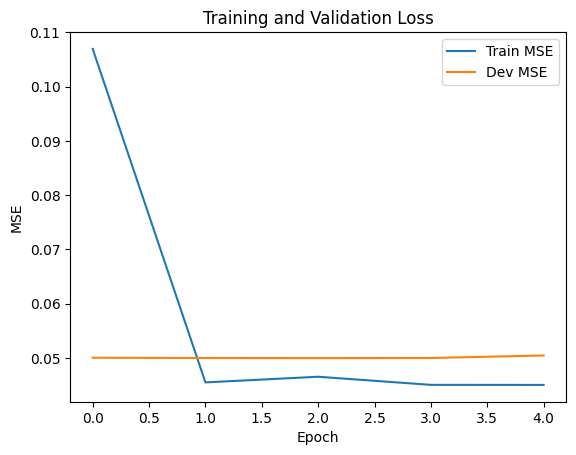

In [94]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train MSE")
plt.plot(dev_losses, label="Dev MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()



In [89]:
def eval_random_baseline(loader, device):
    mse_list = []
    for _, targets in loader:
        targets = targets.to(device)
        preds = torch.rand_like(targets)
        mse_list.append(F.mse_loss(preds, targets).item())
    return sum(mse_list) / len(mse_list)


In [90]:
def eval_model(model, loader, device):
    model.eval()
    mse_list = []

    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            preds = model(imgs)
            mse_list.append(F.mse_loss(preds, targets).item())

    return sum(mse_list) / len(mse_list)


In [91]:
random_mse = eval_random_baseline(test_loader, device)
model_mse  = eval_model(model, test_loader, device)

print(f"Random baseline MSE: {random_mse:.4f}")
print(f"Model MSE:          {model_mse:.4f}")


Random baseline MSE: 0.3208
Model MSE:          0.0399


In [75]:
all_targets = []
for _, t in test_loader:
    all_targets.append(t)
all_targets = torch.cat(all_targets)

print(all_targets.min(), all_targets.max())


tensor(0.) tensor(1.)
